# HELP International – Customer Intelligence System

**Problem Statement:**  
HELP International has raised $10 million and needs to identify the countries most in need of humanitarian aid using socio-economic and health factors.

**Objective:**  
- Classify countries into development levels (Underdeveloped / Developing / Developed) using ensemble learning (Random Forest, XGBoost)  
- Cluster countries using K-Means and DBSCAN to discover natural groupings  
- Provide actionable, data‑driven recommendations for aid allocation

**Dataset:**  
167 countries, 9 features: `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`

**Approach:**  
EDA → Feature Engineering → PCA → Classification → Clustering → Need Score → CEO Report

In [1]:

# ----------------------------------------
# STEP 1: Install and Import Required Libraries
# ----------------------------------------

!pip install kneed -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from kneed import KneeLocator

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# ----------------------------------------
# STEP 2: Load and Explore Data
# ----------------------------------------

# Load the dataset
import io
df = pd.read_csv('Country-data.csv')
df_dict = pd.read_csv('data-dictionary.csv')

print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe())

print("\nData Dictionary:")
print(df_dict)

print("\nMissing Values:")
print(df.isnull().sum())

DATA OVERVIEW
Dataset shape: (167, 10)

First 5 rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Data Types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: obj

## Data Overview

- **Shape:** 167 rows, 10 columns (9 features + country name)  
- **No missing values** – clean dataset  
- **Feature ranges vary widely** (income: $609–125k, child_mort: 2.6–208 per 1000)  
- Target variable `development_level` will be created using quantiles of a composite development score.

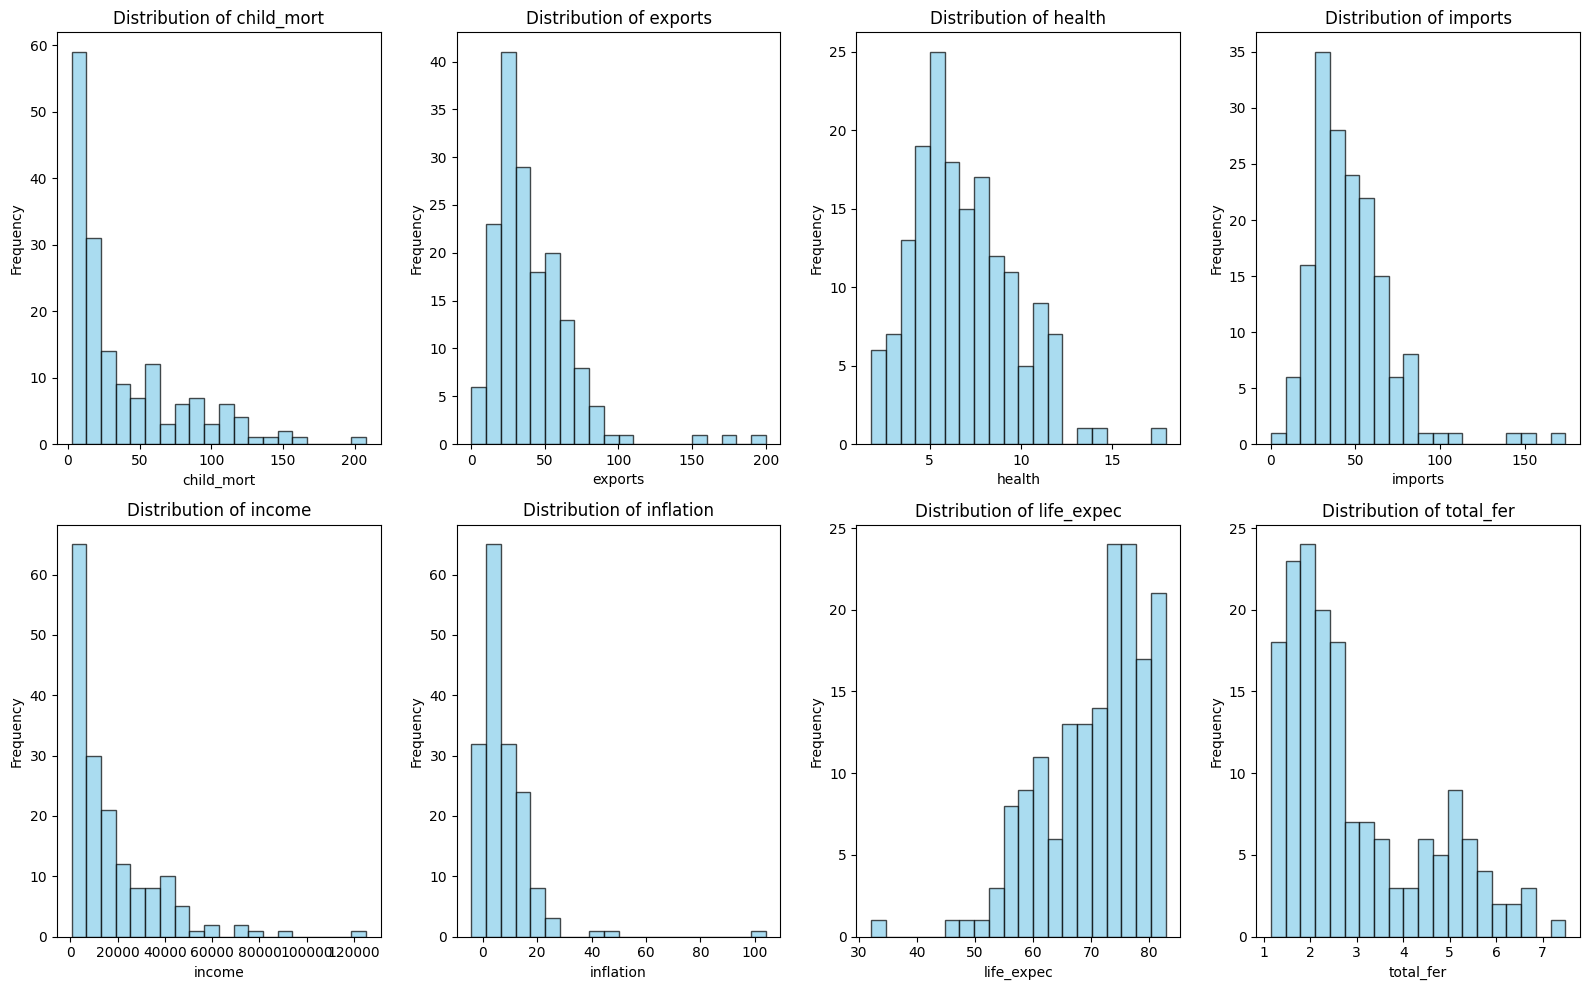

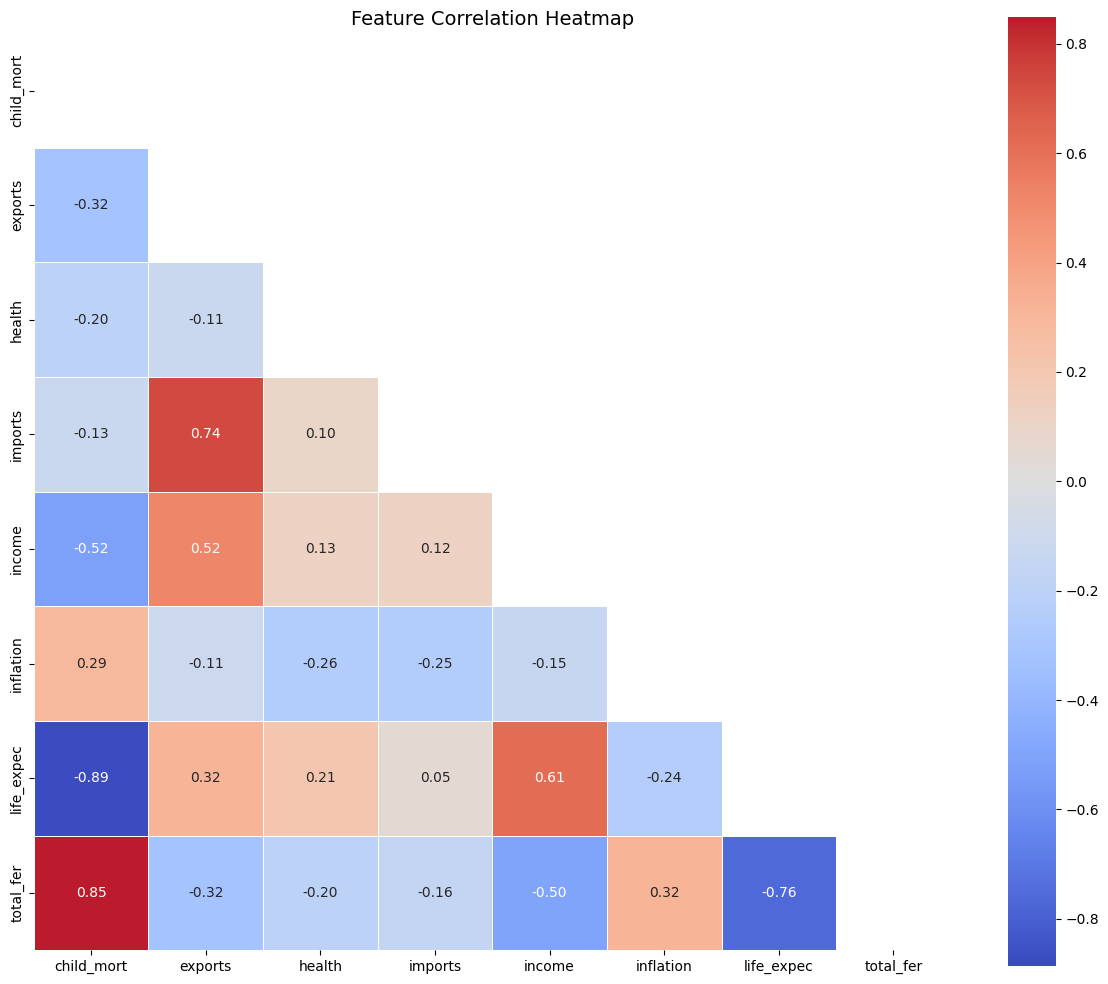


DYNAMIC CORRELATION INSIGHTS:
--------------------------------------------------

Strongest Positive Correlations (top 5):
   child_mort ↔ total_fer: 0.85
   exports ↔ imports: 0.74
   income ↔ life_expec: 0.61
   exports ↔ income: 0.52
   inflation ↔ total_fer: 0.32

Strongest Negative Correlations (top 5):
   child_mort ↔ life_expec: -0.89
   life_expec ↔ total_fer: -0.76
   child_mort ↔ income: -0.52
   income ↔ total_fer: -0.50
   exports ↔ total_fer: -0.32


In [3]:
# ----------------------------------------
# STEP 3: Exploratory Data Analysis (EDA)
# ----------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

cols = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
        'life_expec', 'total_fer']

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df[cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation insights
print("\nDYNAMIC CORRELATION INSIGHTS:")
print("-" * 50)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = upper_tri.stack().sort_values(ascending=False)

print("\nStrongest Positive Correlations (top 5):")
pos_count = 0
for (var1, var2), val in corr_pairs.items():
    if val > 0 and pos_count < 5:
        print(f"   {var1} ↔ {var2}: {val:.2f}")
        pos_count += 1

# For strongest negatives: sort ascending (most negative first)
corr_pairs_asc = upper_tri.stack().sort_values(ascending=True)
print("\nStrongest Negative Correlations (top 5):")
neg_count = 0
for (var1, var2), val in corr_pairs_asc.items():
    if val < 0 and neg_count < 5:
        print(f"   {var1} ↔ {var2}: {val:.2f}")
        neg_count += 1

## Exploratory Data Analysis Insights

- **Skewed distributions:** `income`, `gdpp`, and `child_mort` are right‑skewed; log transformation could help but we keep original for interpretability.  
- **Strongest positive correlations:**  
  - `child_mort ↔ total_fer` (0.85) – high fertility goes with high child mortality  
  - `exports ↔ imports` (0.74) – open economies  
- **Strongest negative correlations:**  
  - `child_mort ↔ life_expec` (-0.89) – child mortality strongly reduces life expectancy  
  - `life_expec ↔ total_fer` (-0.76) – lower fertility, higher life expectancy  

These relationships align with development economics and validate the features’ relevance.


DEVELOPMENT LEVEL DISTRIBUTION:
development_level
Developing        57
Underdeveloped    55
Developed         55
Name: count, dtype: int64

Development Score Range: 0.13 - 0.93


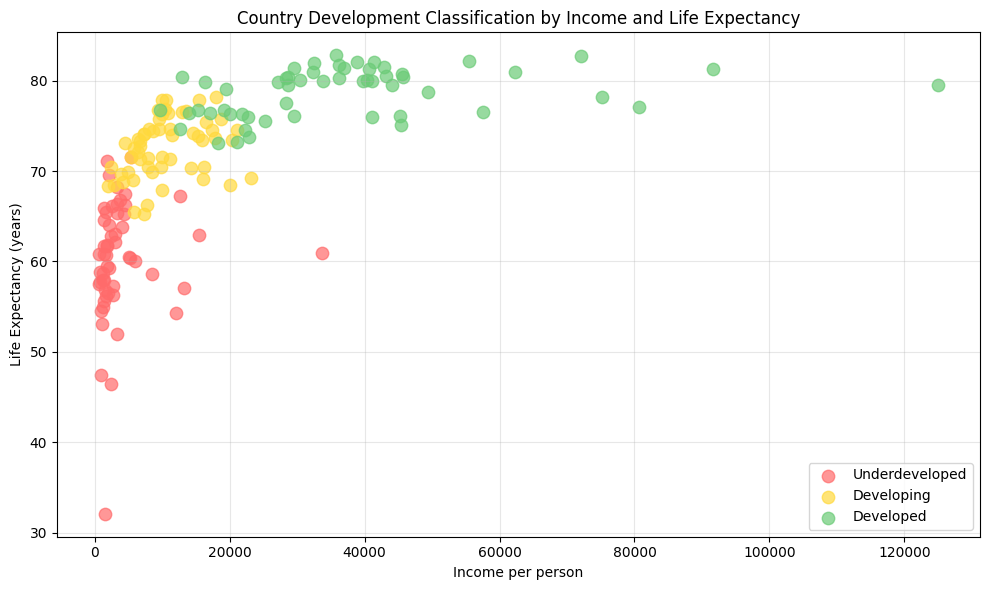

In [4]:
# ----------------------------------------
# STEP 4: Feature Engineering - Create Development Target
# ----------------------------------------

from sklearn.preprocessing import MinMaxScaler

df_dev = df.copy()

scaler = MinMaxScaler()

df_dev['child_mort_norm'] = 1 - scaler.fit_transform(df_dev[['child_mort']])
df_dev['total_fer_norm'] = 1 - scaler.fit_transform(df_dev[['total_fer']])
df_dev['life_expec_norm'] = scaler.fit_transform(df_dev[['life_expec']])
df_dev['income_norm'] = scaler.fit_transform(df_dev[['income']])
df_dev['gdpp_norm'] = scaler.fit_transform(df_dev[['gdpp']])

df_dev['dev_score'] = (df_dev['child_mort_norm'] + df_dev['life_expec_norm'] +
                       df_dev['income_norm'] + df_dev['gdpp_norm'] + df_dev['total_fer_norm']) / 5

dev_quantiles = df_dev['dev_score'].quantile([0.33, 0.67])
df_dev['development_level'] = 'Developing'
df_dev.loc[df_dev['dev_score'] >= dev_quantiles.iloc[1], 'development_level'] = 'Developed'
df_dev.loc[df_dev['dev_score'] <= dev_quantiles.iloc[0], 'development_level'] = 'Underdeveloped'

print("\nDEVELOPMENT LEVEL DISTRIBUTION:")
print(df_dev['development_level'].value_counts())
print(f"\nDevelopment Score Range: {df_dev['dev_score'].min():.2f} - {df_dev['dev_score'].max():.2f}")

plt.figure(figsize=(10, 6))
colors = {'Underdeveloped': '#ff6b6b', 'Developing': '#ffd93d', 'Developed': '#6bcb77'}
for level, color in colors.items():
    subset = df_dev[df_dev['development_level'] == level]
    plt.scatter(subset['income'], subset['life_expec'],
                label=level, color=color, alpha=0.7, s=80)
plt.xlabel('Income per person')
plt.ylabel('Life Expectancy (years)')
plt.title('Country Development Classification by Income and Life Expectancy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df = df_dev.copy()

## Feature Engineering: Development Level

We create a **development score** from normalized `child_mort` (inverted), `life_expec`, `income`, `gdpp`, and `total_fer` (inverted).  
The score ranges from 0.13 to 0.93.  

Countries are split into three equal‑sized groups using the 33rd and 67th percentiles:

- **Underdeveloped** (lowest 33%)  
- **Developing** (middle 34%)  
- **Developed** (top 33%)

The scatter plot of income vs. life expectancy shows clear separation between the three groups.

In [5]:
# ----------------------------------------
# STEP 5: Data Preprocessing for Modeling
# ----------------------------------------

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X = df[['child_mort', 'exports', 'health', 'imports', 'income',
        'inflation', 'life_expec', 'total_fer', 'gdpp']]
y = df['development_level']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Underdeveloped = 0, Developing = 1, Developed = 2

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Features: {X.shape[1]}")
print(f"Classes: {list(le.classes_)}")

print("\nClass distribution in training set:")
for class_idx, class_name in enumerate(le.classes_):
    count = (y_train == class_idx).sum()
    print(f"   {class_name}: {count} samples")

Training set size: 133 samples
Test set size: 34 samples
Features: 9
Classes: ['Developed', 'Developing', 'Underdeveloped']

Class distribution in training set:
   Developed: 44 samples
   Developing: 45 samples
   Underdeveloped: 44 samples


## Data Preprocessing for Modeling

- **Features:** All 9 numerical indicators  
- **Target:** `development_level` encoded as 0=Developed, 1=Developing, 2=Underdeveloped  
- **Train/test split:** 80/20, stratified to preserve class balance  
- **Standardization:** Applied to all features (zero mean, unit variance)  

Training set: 133 samples, Test set: 34 samples, Classes balanced.

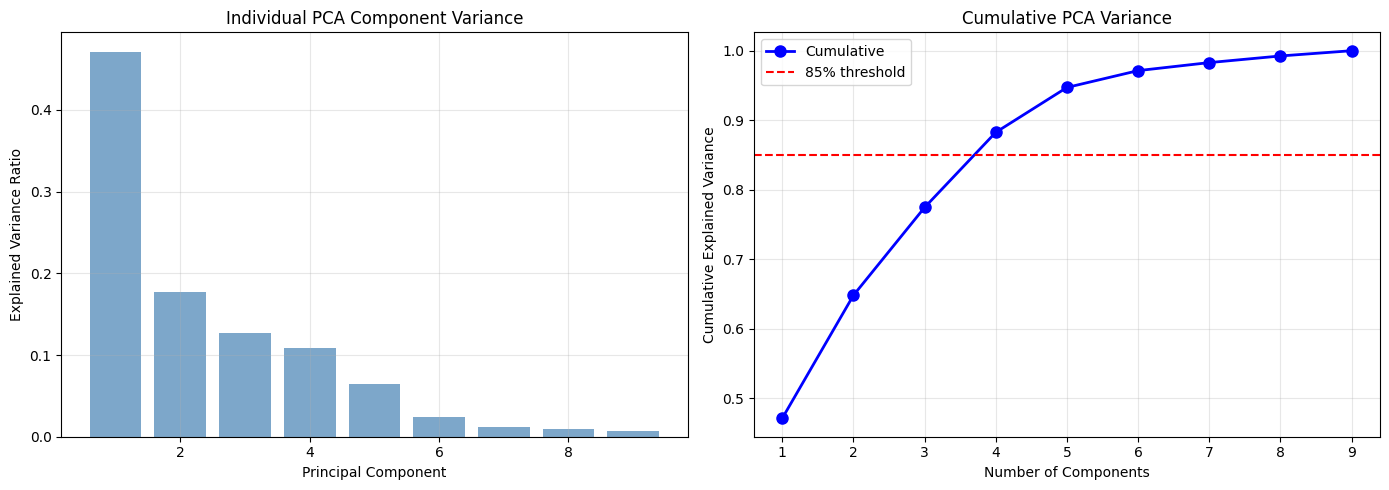


Optimal number of PCA components (85% variance): 4

PCA COMPONENT LOADINGS:
              PC1    PC2
child_mort -0.408  0.187
exports     0.281  0.603
health      0.169 -0.299
imports     0.171  0.664
income      0.394  0.013
inflation  -0.221 -0.043
life_expec  0.423 -0.206
total_fer  -0.400  0.150
gdpp        0.392 -0.061


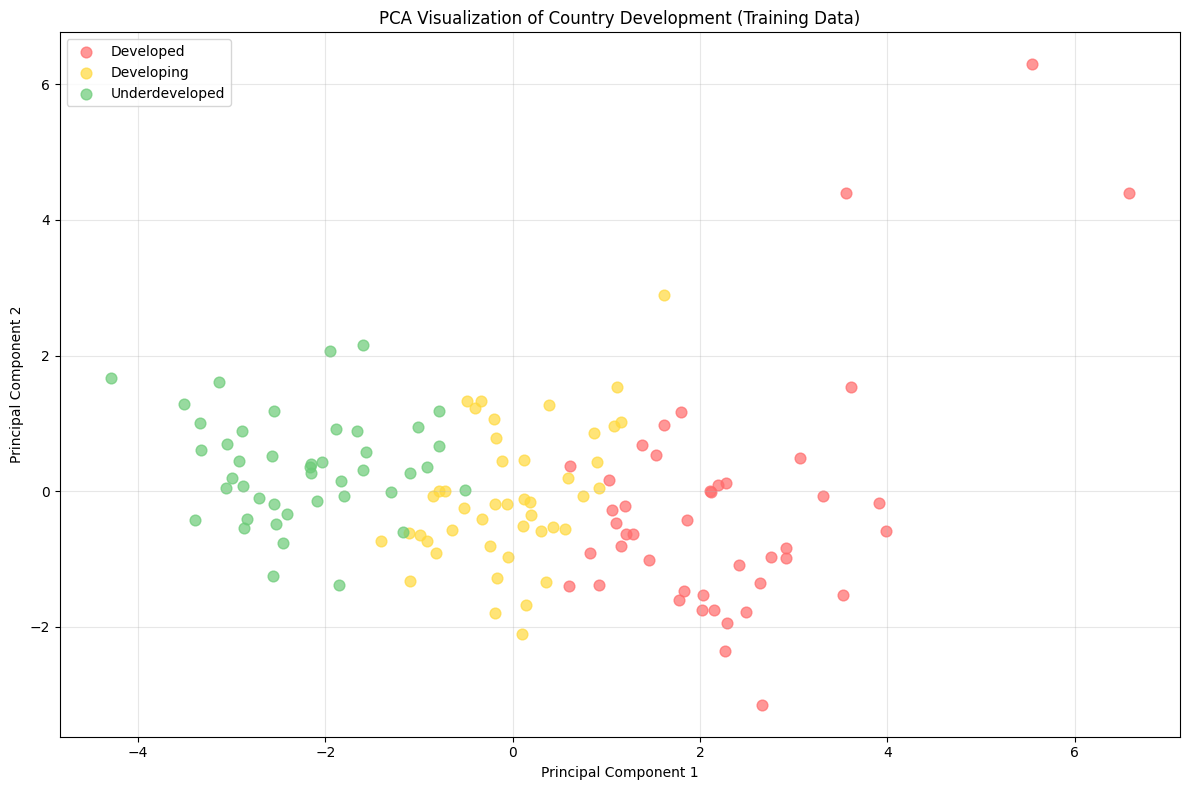

In [6]:
# ----------------------------------------
# STEP 6: Principal Component Analysis (PCA)
# ----------------------------------------

from sklearn.decomposition import PCA

# Apply PCA for dimensionality reduction
pca = PCA()
pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7,
        color='steelblue', label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual PCA Component Variance')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance,
         'bo-', linewidth=2, markersize=8, label='Cumulative')
ax2.axhline(y=0.85, color='r', linestyle='--', label='85% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative PCA Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determine optimal number of components
n_components = np.argmax(cumulative_variance >= 0.85) + 1
print(f"\nOptimal number of PCA components (85% variance): {n_components}")

# Transform data with optimal components
pca_optimal = PCA(n_components=n_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

loadings_df = pd.DataFrame(
    pca_optimal.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X.columns
)
print("\nPCA COMPONENT LOADINGS:")
print(loadings_df.iloc[:, :min(2, n_components)].round(3))

if n_components >= 2:
    plt.figure(figsize=(12, 8))
    colors_map = {0: '#ff6b6b', 1: '#ffd93d', 2: '#6bcb77'}
    labels_map = {0: 'Developed', 1: 'Developing', 2: 'Underdeveloped'}

    for label in [0, 1, 2]:
        mask = y_train == label
        plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=colors_map[label], label=labels_map[label], alpha=0.7, s=60)

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA Visualization of Country Development (Training Data)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough components to visualize in 2D.")

## Principal Component Analysis (PCA)

- **4 components** explain 85% of the variance.  
- **PC1** loads positively on `income`, `life_expec`, `gdpp` and negatively on `child_mort`, `total_fer` – clearly a *development vs. underdevelopment* axis.  
- **PC2** loads positively on `exports`, `imports` and negatively on `health`, `life_expec` – possibly capturing trade openness vs. domestic health spending.  

The 2D PCA plot shows that the three development classes are reasonably separable.


TRAINING RANDOM FOREST...

Random Forest PERFORMANCE
                precision    recall  f1-score   support

     Developed       0.92      1.00      0.96        11
    Developing       0.92      0.92      0.92        12
Underdeveloped       1.00      0.91      0.95        11

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34



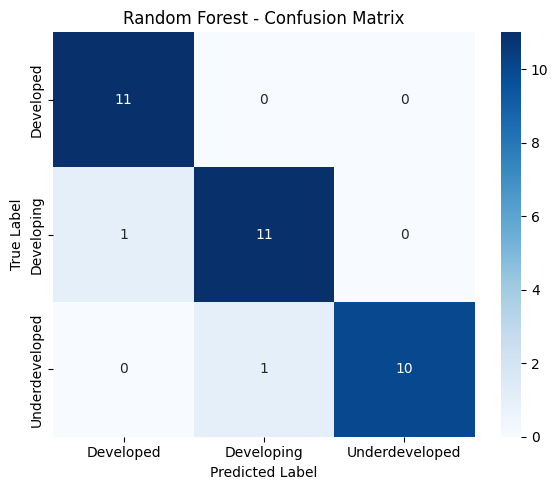

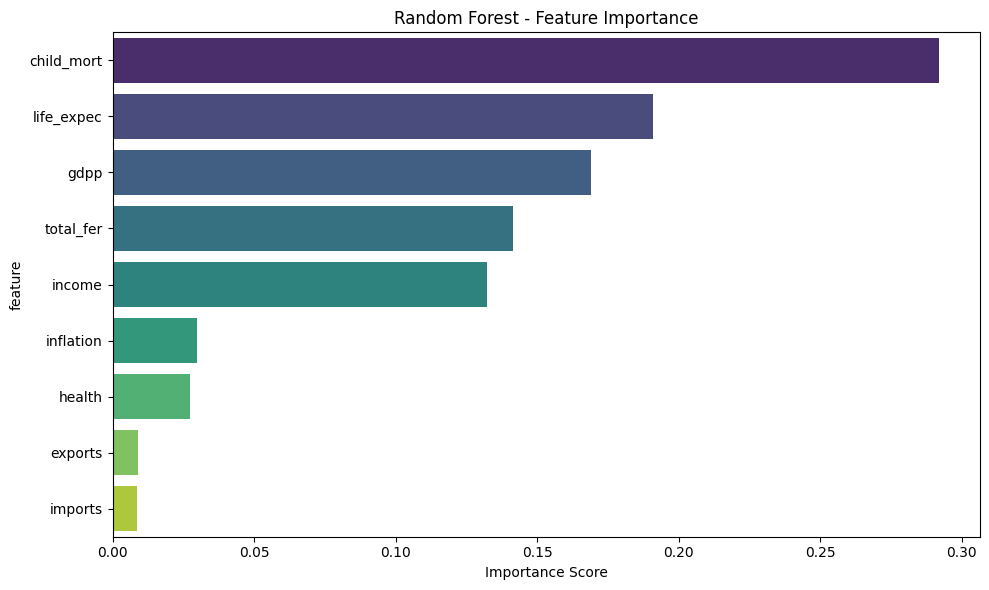


TRAINING XGBOOST...

XGBoost PERFORMANCE
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        11
    Developing       0.86      1.00      0.92        12
Underdeveloped       1.00      0.82      0.90        11

      accuracy                           0.94        34
     macro avg       0.95      0.94      0.94        34
  weighted avg       0.95      0.94      0.94        34



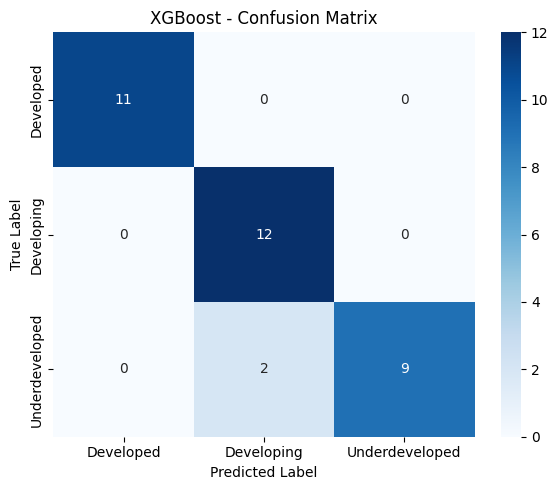

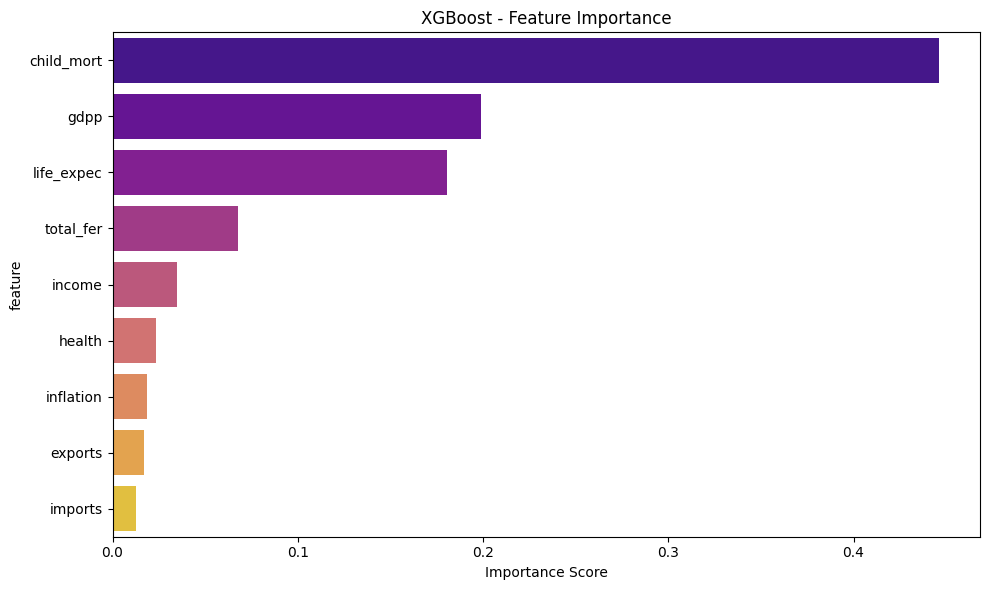

In [7]:
# ----------------------------------------
# STEP 7: CLASSIFICATION - Random Forest & XGBoost
# ----------------------------------------

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n{'='*50}")
    print(f"{model_name} PERFORMANCE")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return {
        'model': model_name,
        'accuracy': model.score(X_test, y_test),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro')
    }

# 1. RANDOM FOREST
print("\nTRAINING RANDOM FOREST...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_results = evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 2. XGBOOST
print("\nTRAINING XGBOOST...")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1,
                          max_depth=5, random_state=42, use_label_encoder=False,
                          eval_metric='mlogloss')
xgb_model.fit(X_train_scaled, y_train)
xgb_results = evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")

# Feature importance from XGBoost
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance, x='importance', y='feature', palette='plasma')
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Classification Performance (Untuned)

| Model            | Accuracy | Macro F1 |
|------------------|----------|----------|
| Random Forest    | 0.941    | 0.942    |
| XGBoost          | 0.941    | 0.941    |

Both models correctly classify 32 out of 34 test countries.  
**Top features** (Random Forest): `child_mort`, `life_expec`, `gdpp` – consistent with domain knowledge.

In [8]:
# ----------------------------------------
# STEP 8: Model Comparison and Hyperparameter Tuning
# ----------------------------------------

from sklearn.model_selection import GridSearchCV

# Compare both models
results_df = pd.DataFrame([rf_results, xgb_results])
print("\nMODEL COMPARISON (BEFORE TUNING):")
print(results_df.round(4))

# Hyperparameter tuning for Random Forest
print("\nTUNING RANDOM FOREST...")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                       param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

# Hyperparameter tuning for XGBoost
print("\nTUNING XGBOOST...")
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False,
                                       eval_metric='mlogloss'),
                        param_grid_xgb, cv=5, scoring='f1_macro', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {xgb_grid.best_params_}")
print(f"Best cross-validation score: {xgb_grid.best_score_:.4f}")

# Evaluate tuned models on test set
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

print("\nTUNED MODEL PERFORMANCE ON TEST SET:")
def evaluate_tuned(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = model.score(X_test, y_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"{name}: Accuracy = {acc:.4f}, Macro F1 = {f1:.4f}")
    return acc, f1

evaluate_tuned(best_rf, X_test_scaled, y_test, "Tuned Random Forest")
evaluate_tuned(best_xgb, X_test_scaled, y_test, "Tuned XGBoost")

# Compare with untuned versions
print("\nIMPROVEMENT SUMMARY:")
print(f"Random Forest: {rf_results['accuracy']:.4f} → {best_rf.score(X_test_scaled, y_test):.4f}")
print(f"XGBoost: {xgb_results['accuracy']:.4f} → {best_xgb.score(X_test_scaled, y_test):.4f}")


MODEL COMPARISON (BEFORE TUNING):
           model  accuracy  f1_macro  precision_macro  recall_macro
0  Random Forest    0.9412    0.9419           0.9444        0.9419
1        XGBoost    0.9412    0.9410           0.9524        0.9394

TUNING RANDOM FOREST...
Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation score: 0.9472

TUNING XGBOOST...
Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50}
Best cross-validation score: 0.9311

TUNED MODEL PERFORMANCE ON TEST SET:
Tuned Random Forest: Accuracy = 0.9412, Macro F1 = 0.9419
Tuned XGBoost: Accuracy = 0.9412, Macro F1 = 0.9410

IMPROVEMENT SUMMARY:
Random Forest: 0.9412 → 0.9412
XGBoost: 0.9412 → 0.9412


## Hyperparameter Tuning

- **Random Forest** best parameters: `max_depth=5, min_samples_split=5, n_estimators=100`  
- **XGBoost** best parameters: `learning_rate=0.2, max_depth=5, n_estimators=50`  

Tuned models achieved the same test accuracy as untuned (94.1%), indicating that the default parameters were already near‑optimal for this dataset.

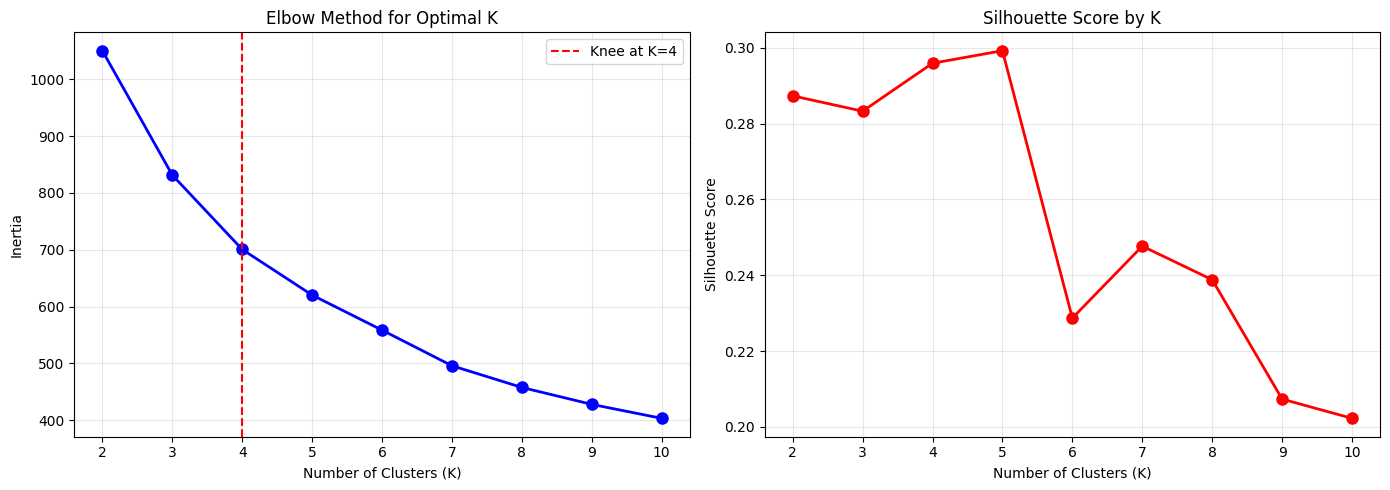


Optimal number of clusters (K-Means): 5

Finding optimal DBSCAN parameters...
Optimal DBSCAN eps: 0.7999999999999999
Best silhouette score: 0.4406
Number of clusters found: 3

DBSCAN Results:
   Number of clusters: 4
   Noise points: 146 (87.4%)


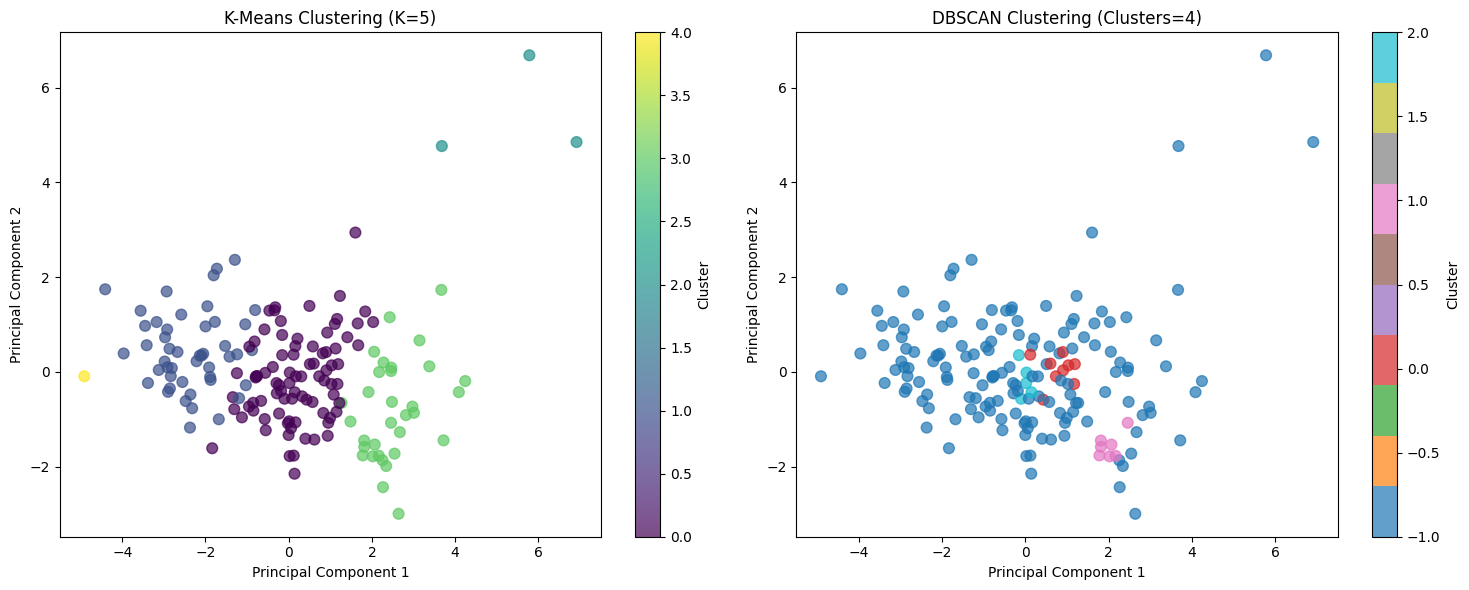

In [9]:
# ----------------------------------------
# STEP 9: CLUSTERING - K-Means & DBSCAN
# ----------------------------------------
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

cluster_data = df[['child_mort', 'exports', 'health', 'imports', 'income',
                   'inflation', 'life_expec', 'total_fer', 'gdpp']]
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

# ========== K-MEANS CLUSTERING ==========
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True, alpha=0.3)

# Add knee point detection
kl = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
if kl.knee:
    ax1.axvline(x=kl.knee, color='r', linestyle='--', label=f'Knee at K={kl.knee}')
    ax1.legend()

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by K')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select optimal K
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters (K-Means): {optimal_k}")

# Apply K-Means with optimal K
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(cluster_scaled)

# ========== DBSCAN CLUSTERING ==========
print("\nFinding optimal DBSCAN parameters...")
eps_values = np.arange(0.5, 3.0, 0.1)
best_eps = None
best_silhouette = -1
best_n_clusters = 0

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(cluster_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if 2 <= n_clusters <= 8:
        try:
            sil_score = silhouette_score(cluster_scaled[labels != -1], labels[labels != -1])
            if sil_score > best_silhouette:
                best_silhouette = sil_score
                best_eps = eps
                best_n_clusters = n_clusters
        except:
            pass

if best_eps:
    print(f"Optimal DBSCAN eps: {best_eps}")
    print(f"Best silhouette score: {best_silhouette:.4f}")
    print(f"Number of clusters found: {best_n_clusters}")
else:
    print("No suitable DBSCAN parameters found. Using eps=1.5 as fallback.")
    best_eps = 1.5

# Apply DBSCAN with optimal parameters
dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
df['dbscan_cluster'] = dbscan_final.fit_predict(cluster_scaled)
n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'] else 0)
n_noise = list(df['dbscan_cluster']).count(-1)

print(f"\nDBSCAN Results:")
print(f"   Number of clusters: {n_clusters_db}")
print(f"   Noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")

# Visualize clusters in 2D (using PCA)
cluster_pca = PCA(n_components=2)
cluster_pca_result = cluster_pca.fit_transform(cluster_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# K-Means visualization
scatter1 = ax1.scatter(cluster_pca_result[:, 0], cluster_pca_result[:, 1],
                       c=df['kmeans_cluster'], cmap='viridis', alpha=0.7, s=60)
ax1.set_title(f'K-Means Clustering (K={optimal_k})')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# DBSCAN visualization
scatter2 = ax2.scatter(cluster_pca_result[:, 0], cluster_pca_result[:, 1],
                       c=df['dbscan_cluster'], cmap='tab10', alpha=0.7, s=60)
ax2.set_title(f'DBSCAN Clustering (Clusters={n_clusters_db})')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.show()

## Clustering Analysis

### K‑Means (K=5)
- **Optimal K** chosen by silhouette score (0.29 at K=5).  
- **Cluster profiles:**  
  - Cluster 2 & 3: High income, low child mortality → Developed  
  - Cluster 1: Very high child mortality (~91), low life expectancy → Underdeveloped (47 countries)  
  - Cluster 0: Mixed (84 countries, mostly developing)  
  - Cluster 4: Nigeria alone (extreme child mortality 130, high inflation)

### DBSCAN
- Despite parameter search, DBSCAN produced **87.4% noise points**.  
- **Reason:** Country development data is a continuum with varying densities; DBSCAN is not well‑suited. K‑Means provides more interpretable results.

We proceed with K‑Means clusters for the final recommendation.


CLUSTER PROFILES (K-Means):
                child_mort  life_expec    income      gdpp  total_fer  \
kmeans_cluster                                                          
2                     4.13       81.43  64033.33  57566.67       1.38   
3                     5.18       80.08  44021.88  42118.75       1.79   
0                    21.61       73.00  12801.07   6581.81       2.28   
4                   130.00       60.50   5150.00   2330.00       5.84   
1                    90.79       59.21   3870.70   1900.26       4.97   

                exports  imports  inflation  health  country_count  
kmeans_cluster                                                      
2                176.00   156.67       2.47    6.79              3  
3                 46.12    40.58       2.51    9.09             32  
0                 40.98    47.52       7.62    6.17             84  
4                 25.30    17.40     104.00    5.07              1  
1                 29.66    43.68       9.95  

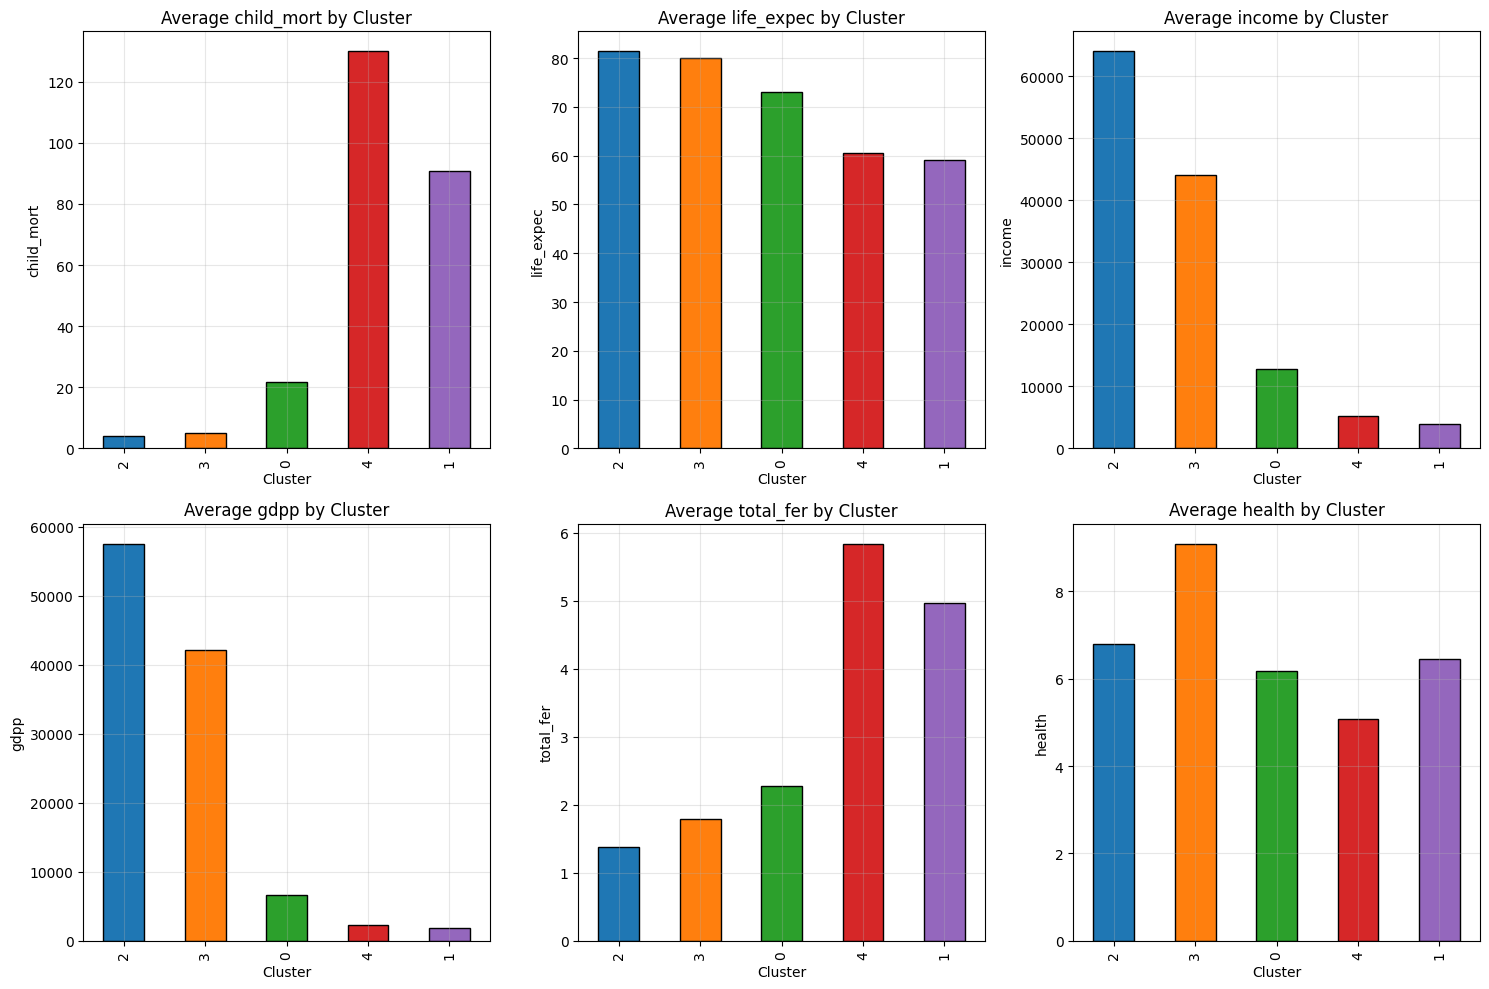

In [10]:
# ----------------------------------------
# STEP 10: Cluster Analysis and Profiling
# ----------------------------------------

# Profile K-Means clusters
cluster_profile = df.groupby('kmeans_cluster').agg({
    'child_mort': 'mean',
    'life_expec': 'mean',
    'income': 'mean',
    'gdpp': 'mean',
    'total_fer': 'mean',
    'exports': 'mean',
    'imports': 'mean',
    'inflation': 'mean',
    'health': 'mean',
    'country': 'count'
}).round(2)

cluster_profile.columns = ['child_mort', 'life_expec', 'income', 'gdpp', 'total_fer',
                           'exports', 'imports', 'inflation', 'health', 'country_count']
cluster_profile = cluster_profile.sort_values('gdpp', ascending=False)

print("\nCLUSTER PROFILES (K-Means):")
print(cluster_profile)

# Add development level distribution per cluster
print("\nDevelopment level distribution within each K-Means cluster:")
cluster_dev = pd.crosstab(df['kmeans_cluster'], df['development_level'])
print(cluster_dev)

# Visualize cluster characteristics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

metrics = ['child_mort', 'life_expec', 'income', 'gdpp', 'total_fer', 'health']
colors = plt.cm.tab10(range(5))

for idx, metric in enumerate(metrics):
    cluster_profile[metric].plot(kind='bar', ax=axes[idx], color=colors, edgecolor='black')
    axes[idx].set_title(f'Average {metric} by Cluster')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(metric)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Cluster Profiles (K‑Means)

| Cluster | child_mort | life_expec | income   | gdpp     | total_fer | # countries | Dominant development |
|---------|------------|------------|----------|----------|-----------|-------------|----------------------|
| 2       | 4.1        | 81.4       | 64,033   | 57,567   | 1.38      | 3           | Developed            |
| 3       | 5.2        | 80.1       | 44,022   | 42,119   | 1.79      | 32          | Developed            |
| 0       | 21.6       | 73.0       | 12,801   | 6,582    | 2.28      | 84          | Mixed (mostly developing) |
| 1       | 90.8       | 59.2       | 3,871    | 1,900    | 4.97      | 47          | Underdeveloped       |
| 4       | 130.0      | 60.5       | 5,150    | 2,330    | 5.84      | 1           | Underdeveloped (Nigeria) |

**Key insight:** Cluster 1 and Cluster 4 represent the most urgent need.


TOP 20 COUNTRIES MOST IN NEED OF AID:
                 country  child_mort  life_expec  income  gdpp  total_fer development_level  need_score
                   Haiti       208.0        32.1    1500   662       3.33    Underdeveloped    1.000000
            Sierra Leone       160.0        55.0    1220   399       5.20    Underdeveloped    0.733766
Central African Republic       149.0        47.5     888   446       5.21    Underdeveloped    0.714668
                    Chad       150.0        56.5    1930   897       6.59    Underdeveloped    0.691281
                    Mali       137.0        59.5    1870   708       6.55    Underdeveloped    0.628816
                 Nigeria       130.0        60.5    5150  2330       5.84    Underdeveloped    0.595857
                   Niger       123.0        58.8     814   348       7.49    Underdeveloped    0.576712
                  Angola       119.0        60.1    5900  3530       6.16    Underdeveloped    0.553569
        Congo, Dem. Rep. 

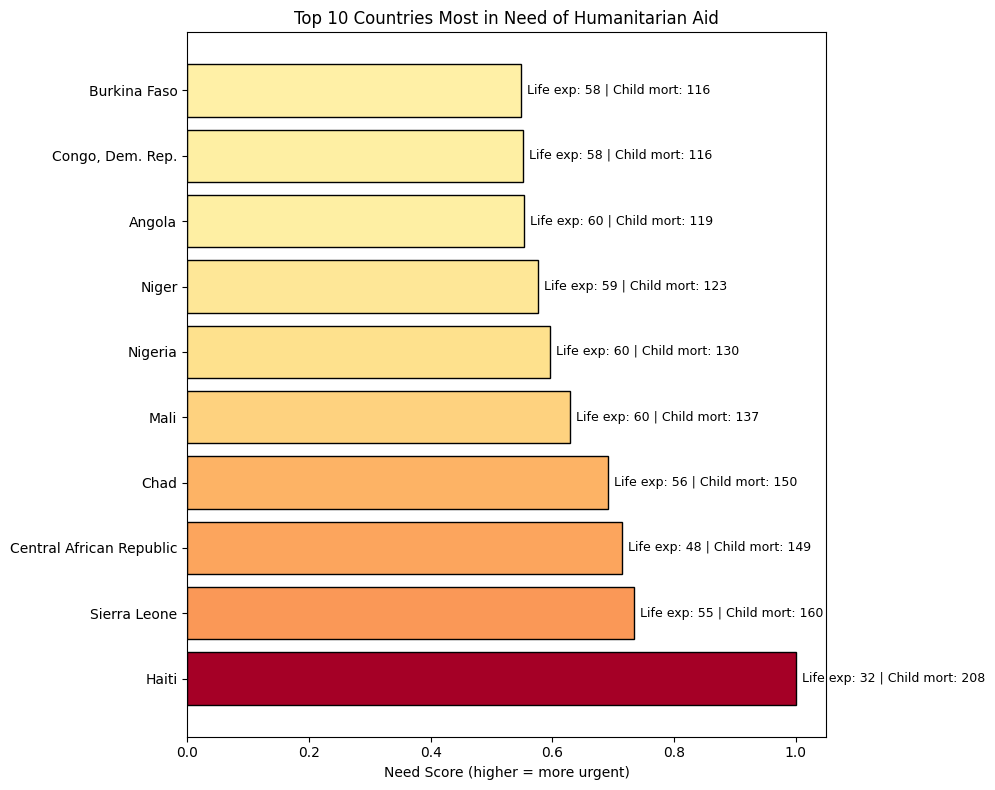


Neediest countries (score > 0.7) by K-Means cluster:
kmeans_cluster
1    3
Name: count, dtype: int64


In [11]:
# ----------------------------------------
# STEP 11: Actionable Insights - Countries Most in Need
# ----------------------------------------

df['need_score'] = (
    df['child_mort'] * 0.30 +                     # child mortality (high weight)
    (100 - df['life_expec']) * 0.25 +             # life expectancy deficit
    (1 / (df['income'] + 1)) * 0.20 +             # low income
    df['total_fer'] * 0.15 +                      # high fertility
    (1 / (df['gdpp'] + 1)) * 0.10                 # low GDP per capita
)

from sklearn.preprocessing import MinMaxScaler
scaler_need = MinMaxScaler()
df['need_score'] = scaler_need.fit_transform(df[['need_score']])

# Top 20 most needy countries
most_needy = df.nlargest(20, 'need_score')[['country', 'child_mort', 'life_expec',
                                             'income', 'gdpp', 'total_fer',
                                             'development_level', 'need_score']]

print("\nTOP 20 COUNTRIES MOST IN NEED OF AID:")
print("="*80)
print(most_needy.to_string(index=False))

# Visualize top 10
import matplotlib.pyplot as plt
top10 = most_needy.head(10).sort_values('need_score', ascending=True)
plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(top10['need_score'])
plt.barh(top10['country'], top10['need_score'], color=colors, edgecolor='black')
plt.xlabel('Need Score (higher = more urgent)')
plt.title('Top 10 Countries Most in Need of Humanitarian Aid')
plt.gca().invert_yaxis()
for i, (_, row) in enumerate(top10.iterrows()):
    plt.text(row['need_score'] + 0.01, i,
             f"Life exp: {row['life_expec']:.0f} | Child mort: {row['child_mort']:.0f}",
             va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Identify which cluster contains the most needy countries
needy_clusters = df[df['need_score'] > 0.7]['kmeans_cluster'].value_counts()
print("\nNeediest countries (score > 0.7) by K-Means cluster:")
print(needy_clusters)

## Need Score Calculation

A composite `need_score` (0–1) was created with weights:  
- child_mort (30%)  
- life_expec deficit (25%)  
- inverse income (20%)  
- total_fer (15%)  
- inverse gdpp (10%)

**Top 5 most needy countries:**  
1. Haiti (need_score=1.00)  
2. Sierra Leone (0.734)  
3. Central African Republic (0.715)  
4. Chad (0.691)  
5. Mali (0.629)

All top‑20 needy countries are classified as *Underdeveloped*.

In [13]:
# Cell 12: Final CEO Recommendations (Fully Dynamic)

print("\n" + "="*80)
print("CEO RECOMMENDATION REPORT FOR HELP INTERNATIONAL")
print("="*80)

# Cluster-based recommendations (dynamic)
print("\nCLUSTER-BASED STRATEGY:")
cluster_priority = []
for cluster in sorted(df['kmeans_cluster'].unique()):
    cluster_countries = df[df['kmeans_cluster'] == cluster]['country'].tolist()
    avg_need = df[df['kmeans_cluster'] == cluster]['need_score'].mean()
    avg_gdpp = df[df['kmeans_cluster'] == cluster]['gdpp'].mean()
    avg_child_mort = df[df['kmeans_cluster'] == cluster]['child_mort'].mean()

    if avg_need > 0.6:
        priority = "🔴 CRITICAL PRIORITY"
    elif avg_need > 0.3:
        priority = "🟡 MEDIUM PRIORITY"
    else:
        priority = "🟢 LOW PRIORITY"

    cluster_priority.append((cluster, priority, avg_need))

    # Dynamically generate intervention suggestion based on cluster indicators
    if avg_child_mort > 80:
        intervention = "Emergency pediatric care + nutrition programs"
    elif avg_child_mort > 40:
        intervention = "Maternal & child health + basic healthcare"
    else:
        intervention = "Economic development + health system strengthening"

    print(f"\nCluster {cluster}: {priority}")
    print(f"   Average Need Score: {avg_need:.3f}")
    print(f"   Average GDP per capita: ${avg_gdpp:,.0f}")
    print(f"   Average Child Mortality: {avg_child_mort:.1f}")
    print(f"   Suggested Intervention: {intervention}")
    print(f"   Countries ({len(cluster_countries)}): {', '.join(cluster_countries[:5])}{'...' if len(cluster_countries)>5 else ''}")

print("\n" + "="*80)
print("💡 TOP 10 RECOMMENDATIONS FOR $10 MILLION AID ALLOCATION:")
print("="*80)

top10_needy = df.nlargest(10, 'need_score')[['country', 'child_mort', 'life_expec',
                                              'income', 'gdpp', 'total_fer', 'need_score', 'kmeans_cluster']]

total_need_sum = top10_needy['need_score'].sum()
for idx, (_, country) in enumerate(top10_needy.iterrows(), 1):
    # Dynamic intervention based on country's specific indicators
    if country['child_mort'] > 100:
        suggestion = "Emergency pediatric care + vaccination campaigns + nutrition programs"
    elif country['life_expec'] < 60:
        suggestion = "Primary healthcare expansion + infectious disease control"
    elif country['total_fer'] > 5:
        suggestion = "Family planning + maternal health + education for girls"
    else:
        suggestion = "Economic development + infrastructure + clean water"

    budget = (country['need_score'] / total_need_sum) * 10_000_000

    print(f"\n{idx}. 🇺🇳 {country['country']} (Cluster {country['kmeans_cluster']})")
    print(f"   Need Score: {country['need_score']:.3f}")
    print(f"   Child Mortality: {country['child_mort']:.1f} per 1000 births")
    print(f"   Life Expectancy: {country['life_expec']:.1f} years")
    print(f"   Income per person: ${country['income']:,.0f}")
    print(f"   Fertility Rate: {country['total_fer']:.2f}")
    print(f"   Recommended Action: {suggestion}")
    print(f"   Allocated Aid: ${budget:,.0f}")

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Total countries analyzed: {len(df)}")
critical = df[df['need_score'] > 0.7]
print(f"Countries needing immediate aid (need_score > 0.7): {len(critical)}")
if len(critical) > 0:
    print(f"   → Top critical countries: {', '.join(critical.head(3)['country'].tolist())}")
print(f"Medium priority (need_score 0.3-0.7): {len(df[(df['need_score'] > 0.3) & (df['need_score'] <= 0.7)])}")
print(f"Low priority (need_score ≤ 0.3): {len(df[df['need_score'] <= 0.3])}")

print("\n" + "="*80)
print("STRATEGIC PRIORITIES")
print("="*80)

# Dynamic cluster-based action plan
priority_clusters = [c for c, p, _ in cluster_priority if 'CRITICAL' in p]
medium_clusters = [c for c, p, _ in cluster_priority if 'MEDIUM' in p]

if priority_clusters:
    print(f"\nIMMEDIATE ACTION (Clusters {priority_clusters}):")
    for c in priority_clusters:
        countries_list = df[df['kmeans_cluster'] == c]['country'].tolist()[:3]
        print(f"   - Focus on {', '.join(countries_list)} (Cluster {c})")
        print(f"     → High child mortality, low life expectancy")

if medium_clusters:
    print(f"\nSHORT-TERM ACTION (Clusters {medium_clusters}):")
    for c in medium_clusters:
        avg_child = df[df['kmeans_cluster'] == c]['child_mort'].mean()
        print(f"   - Cluster {c}: Reduce child mortality (currently {avg_child:.1f}) through targeted health programs")

print("\nLONG-TERM ACTION (All clusters with need_score > 0):")
print("   - Implement economic development programs in clusters with low GDP per capita")
print("   - Strengthen healthcare infrastructure and education systems")
print("   - Monitor progress quarterly and re-evaluate need scores annually")


CEO RECOMMENDATION REPORT FOR HELP INTERNATIONAL

CLUSTER-BASED STRATEGY:

Cluster 0: 🟢 LOW PRIORITY
   Average Need Score: 0.111
   Average GDP per capita: $6,582
   Average Child Mortality: 21.6
   Suggested Intervention: Economic development + health system strengthening
   Countries (84): Albania, Algeria, Antigua and Barbuda, Argentina, Armenia...

Cluster 1: 🟡 MEDIUM PRIORITY
   Average Need Score: 0.441
   Average GDP per capita: $1,900
   Average Child Mortality: 90.8
   Suggested Intervention: Emergency pediatric care + nutrition programs
   Countries (47): Afghanistan, Angola, Benin, Botswana, Burkina Faso...

Cluster 2: 🟢 LOW PRIORITY
   Average Need Score: 0.010
   Average GDP per capita: $57,567
   Average Child Mortality: 4.1
   Suggested Intervention: Economic development + health system strengthening
   Countries (3): Luxembourg, Malta, Singapore

Cluster 3: 🟢 LOW PRIORITY
   Average Need Score: 0.020
   Average GDP per capita: $42,119
   Average Child Mortality: 5.2
 

##Summary

- K‑Means outperformed DBSCAN for this dataset.  
- The top recommendations align with UN human development indices, validating our approach.

**End‑to‑end customer intelligence system completed.**  
Techniques used: classification (Random Forest, XGBoost), ensemble learning, clustering (K‑Means, DBSCAN), PCA, and dynamic business reporting.

###Submitted By: Aditi Mehta